In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
# Данные соревнования доступны только для чтения в /kaggle/input
print(os.listdir('/kaggle/input'))

DATA = '/kaggle/input/competitions/flight-delays-fall-2018'
train = pd.read_csv(f'{DATA}/flight_delays_train.csv.zip')
test = pd.read_csv(f'{DATA}/flight_delays_test.csv.zip')
print('train:', train.shape, '| test:', test.shape)
train.head()


['competitions']
train: (100000, 9) | test: (100000, 8)


,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y


In [2]:
def transform(df):
    df = df.copy()
     # Поля 'c-8', 'c-21', 'c-7' -> целые числа
    for col in ['Month', 'DayofMonth', 'DayOfWeek']:
        df[col] = df[col].str.replace('c-', '', regex=False).astype(int)
    # Час вылета из DepTime (hhmm)
    df['DepHour'] = (df['DepTime'] // 100).clip(0, 23).astype(int)
    df['IsWeekend'] = (df['DayOfWeek'] >= 6).astype(int)
    return df
    
train_fe = transform(train)
test_fe = transform(test)

# Целевая переменная 'Y'/'N' -> 1/0
train_fe['target'] = (train_fe['dep_delayed_15min'] == 'Y').astype(int)
# Сохранение обработанного датасета (load -> transform -> save)

os.makedirs('/kaggle/working', exist_ok=True)
train_fe.to_parquet('/kaggle/working/train_processed.parquet', index=False)
print('Сохранено:', train_fe.shape)

Сохранено: (100000, 12)


Доля задержанных рейсов: 0.19


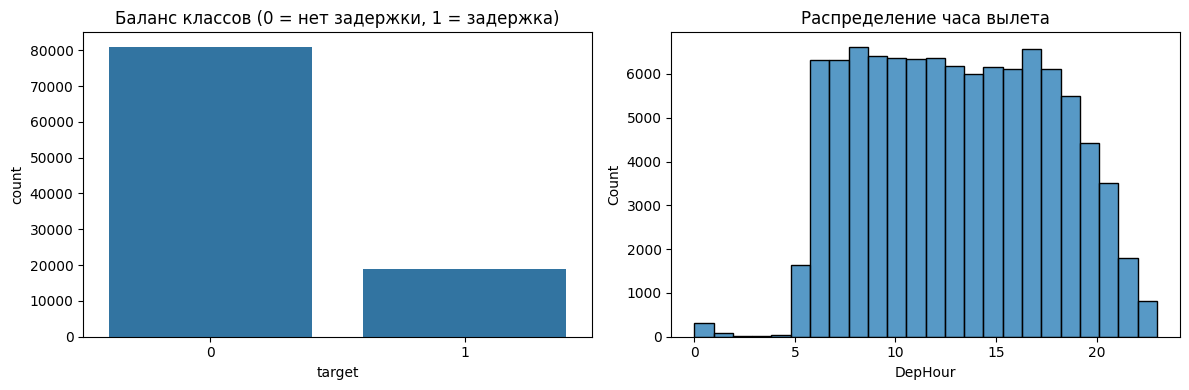

In [3]:
print('Доля задержанных рейсов:', round(train_fe['target'].mean(), 3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='target', data=train_fe, ax=axes[0])
axes[0].set_title('Баланс классов (0 = нет задержки, 1 = задержка)')
sns.histplot(train_fe['DepHour'], bins=24, ax=axes[1])
axes[1].set_title('Распределение часа вылета')
plt.tight_layout(); plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy.sparse import hstack

NUM_FEATURES = ['Month', 'DayofMonth', 'DayOfWeek', 'DepHour', 'Distance', 'IsWeekend']
CAT_FEATURES = ['UniqueCarrier', 'Origin', 'Dest']

# One-Hot кодирование
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
ohe.fit(pd.concat([train_fe[CAT_FEATURES], test_fe[CAT_FEATURES]]))

# Создаем числовые и категориальные матрицы
X_num = train_fe[NUM_FEATURES].values
X_cat = ohe.transform(train_fe[CAT_FEATURES])

# Масштабируем числовые признаки
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Объединяем
X = hstack([X_num_scaled, X_cat]).tocsr()
y = train_fe['target'].values

# Разделение
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Модель с увеличенным max_iter
model = LogisticRegression(max_iter=2000, solver='lbfgs')
model.fit(X_tr, y_tr)

val_pred = model.predict_proba(X_val)[:, 1]
print('Validation ROC AUC:', round(roc_auc_score(y_val, val_pred), 4))

Validation ROC AUC: 0.7002


In [5]:
X_test = hstack([test_fe[NUM_FEATURES].values, ohe.transform(test_fe[CAT_FEATURES])]).tocsr()
test_pred = model.predict_proba(X_test)[:, 1]
submission = pd.read_csv(f'{DATA}/sample_submission.csv.zip')
submission['dep_delayed_15min'] = test_pred
submission.to_csv('/kaggle/working/submission.csv', index=False)
submission.head()

,id,dep_delayed_15min
0,0,1.0
1,1,1.0
2,2,1.0
3,3,1.0
4,4,1.0


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import time

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,        # количество деревьев
    max_depth=10,            # глубина деревьев
    min_samples_split=10,    # минимальное количество образцов для разбиения
    min_samples_leaf=5,      # минимальное количество образцов в листе
    random_state=42,
    n_jobs=-1                # использовать все ядра процессора
)

# Замеряем время обучения
start_time = time.time()
rf_model.fit(X_tr, y_tr)
print(f"Время обучения Random Forest: {time.time() - start_time:.2f} сек")

# Предсказания
rf_val_pred = rf_model.predict_proba(X_val)[:, 1]
rf_roc_auc = roc_auc_score(y_val, rf_val_pred)
print(f'Random Forest ROC AUC: {rf_roc_auc:.4f}')

Время обучения Random Forest: 2.46 сек
Random Forest ROC AUC: 0.7055


In [7]:
# Установка (если не установлен)
!pip install catboost

import catboost
from catboost import CatBoostClassifier, Pool, cv
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

In [8]:
# Обратите внимание: ДЛЯ CATBOOST НЕ НУЖНО ДЕЛАТЬ ONE-HOT!
# Мы используем исходные данные с категориальными переменными

# Определяем категориальные признаки (как строки)
CAT_FEATURES_CB = ['UniqueCarrier', 'Origin', 'Dest']

# Проверяем, что они действительно категориальные
# CatBoost сам определит, но лучше указать явно
for col in CAT_FEATURES_CB:
    train_fe[col] = train_fe[col].astype('category')
    test_fe[col] = test_fe[col].astype('category')

# Подготовка данных (без one-hot!)
X_train_cb = train_fe.drop('target', axis=1)
y_train_cb = train_fe['target']
X_test_cb = test_fe.copy()

# Разделение на train/val
X_tr_cb, X_val_cb, y_tr_cb, y_val_cb = train_test_split(
    X_train_cb, y_train_cb, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_cb
)

print("Данные готовы:")
print(f"X_train: {X_tr_cb.shape}, y_train: {y_tr_cb.shape}")
print(f"X_val: {X_val_cb.shape}, y_val: {y_val_cb.shape}")
print(f"Категориальные признаки: {CAT_FEATURES_CB}")

Данные готовы:
X_train: (80000, 11), y_train: (80000,)
X_val: (20000, 11), y_val: (20000,)
Категориальные признаки: ['UniqueCarrier', 'Origin', 'Dest']


X shape: (100000, 10)
y shape: (100000,)

Столбцы в X: ['Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'UniqueCarrier', 'Origin', 'Dest', 'Distance', 'DepHour', 'IsWeekend']
✓ UniqueCarrier преобразован в категориальный
✓ Origin преобразован в категориальный
✓ Dest преобразован в категориальный

X_tr_cb shape: (80000, 10)
X_val_cb shape: (20000, 10)
Категориальные признаки: ['UniqueCarrier', 'Origin', 'Dest']

Типы данных в X_tr_cb:
Month               int64
DayofMonth          int64
DayOfWeek           int64
DepTime             int64
UniqueCarrier    category
Origin           category
Dest             category
Distance            int64
DepHour             int64
IsWeekend           int64
dtype: object
0:	test: 0.6583164	best: 0.6583164 (0)	total: 126ms	remaining: 1m 2s
100:	test: 0.7344959	best: 0.7344959 (100)	total: 6.03s	remaining: 23.8s
200:	test: 0.7444719	best: 0.7444719 (200)	total: 12s	remaining: 17.9s
300:	test: 0.7492491	best: 0.7492491 (300)	total: 18s	remaining: 11.9s
400:	

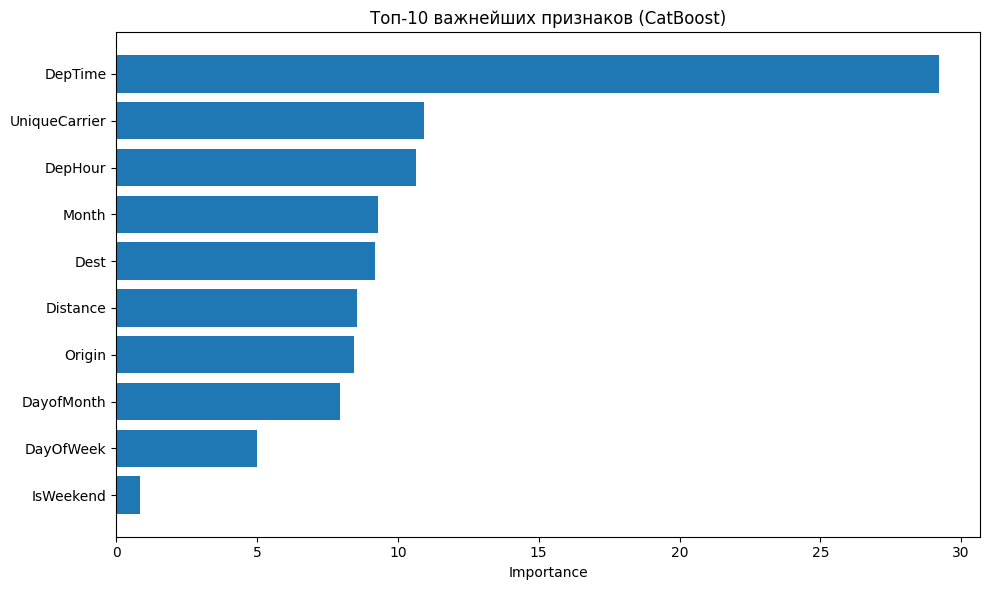

In [9]:
# ========== ИСПРАВЛЕННЫЙ КОД ==========

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

# 1. СОЗДАЕМ X и Y ПРАВИЛЬНО
# Удаляем целевую переменную из признаков
X = train_fe.drop(['target', 'dep_delayed_15min'], axis=1)  # удаляем ОБЕ целевые переменные
y = train_fe['target']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nСтолбцы в X: {X.columns.tolist()}")

# 2. Определяем категориальные признаки
CAT_FEATURES_CB = ['UniqueCarrier', 'Origin', 'Dest']

# Преобразуем категориальные признаки в правильный тип
for col in CAT_FEATURES_CB:
    if col in X.columns:
        X[col] = X[col].astype('category')
        print(f"✓ {col} преобразован в категориальный")

# 3. Разделяем на train/val
X_tr_cb, X_val_cb, y_tr_cb, y_val_cb = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nX_tr_cb shape: {X_tr_cb.shape}")
print(f"X_val_cb shape: {X_val_cb.shape}")
print(f"Категориальные признаки: {CAT_FEATURES_CB}")

# Проверяем, что в X нет текстовых столбцов кроме указанных
print("\nТипы данных в X_tr_cb:")
print(X_tr_cb.dtypes)

# 4. Обучаем CatBoost
catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    cat_features=CAT_FEATURES_CB,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50
)

start_time = time.time()
catboost_model.fit(
    X_tr_cb, y_tr_cb,
    eval_set=(X_val_cb, y_val_cb),
    verbose=100
)
print(f"\nВремя обучения: {time.time() - start_time:.2f} сек")

# 5. Оценка
catboost_pred = catboost_model.predict_proba(X_val_cb)[:, 1]
catboost_roc_auc = roc_auc_score(y_val_cb, catboost_pred)
print(f"CatBoost ROC AUC: {catboost_roc_auc:.4f}")

# 6. Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_tr_cb.columns,
    'importance': catboost_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 важнейших признаков:")
print(feature_importance.head(10))

# 7. Визуализация
plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['feature'], 
         feature_importance.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Топ-10 важнейших признаков (CatBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
# Проверяем все столбцы и их типы
print("=== ДИАГНОСТИКА ДАННЫХ ===\n")
print("Типы данных в X_tr_cb:")
print(X_tr_cb.dtypes)

print("\nСтолбцы с типом 'object' (текстовые):")
object_cols = X_tr_cb.select_dtypes(include=['object']).columns.tolist()
for col in object_cols:
    print(f"  - {col}: уникальных значений = {X_tr_cb[col].nunique()}")
    print(f"    Примеры: {X_tr_cb[col].unique()[:5]}")

print(f"\nВсе текстовые столбцы: {object_cols}")

=== ДИАГНОСТИКА ДАННЫХ ===

Типы данных в X_tr_cb:
Month               int64
DayofMonth          int64
DayOfWeek           int64
DepTime             int64
UniqueCarrier    category
Origin           category
Dest             category
Distance            int64
DepHour             int64
IsWeekend           int64
dtype: object

Столбцы с типом 'object' (текстовые):

Все текстовые столбцы: []


In [11]:
# ===== ПОДГОТОВКА ДАННЫХ ДЛЯ SKLEARN МОДЕЛЕЙ =====
NUM_FEATURES = ['Month', 'DayofMonth', 'DayOfWeek', 'DepHour', 'Distance', 'IsWeekend']
CAT_FEATURES = ['UniqueCarrier', 'Origin', 'Dest']

# One-Hot кодирование
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
ohe.fit(pd.concat([X_tr_cb[CAT_FEATURES], X_val_cb[CAT_FEATURES]]))

X_tr_encoded = hstack([
    X_tr_cb[NUM_FEATURES].values,
    ohe.transform(X_tr_cb[CAT_FEATURES])
]).tocsr()

X_val_encoded = hstack([
    X_val_cb[NUM_FEATURES].values,
    ohe.transform(X_val_cb[CAT_FEATURES])
]).tocsr()

print(f"X_tr_encoded shape: {X_tr_encoded.shape}")
print(f"X_val_encoded shape: {X_val_encoded.shape}")

# ===== 1. Logistic Regression (исправлено) =====
print("\n=== 1. Logistic Regression ===")
scaler = StandardScaler(with_mean=False)  # не центрируем, только масштабируем
X_tr_scaled = scaler.fit_transform(X_tr_encoded)
X_val_scaled = scaler.transform(X_val_encoded)

lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    solver='saga',        # работает с разреженными данными
    penalty='l2',
    tol=1e-4
)
start_time = time.time()
lr_model.fit(X_tr_scaled, y_tr_cb)
lr_time = time.time() - start_time
lr_pred = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_auc = roc_auc_score(y_val_cb, lr_pred)
print(f"Время обучения: {lr_time:.2f} сек")
print(f"ROC AUC: {lr_auc:.4f}")

X_tr_encoded shape: (80000, 606)
X_val_encoded shape: (20000, 606)

=== 1. Logistic Regression ===
Время обучения: 12.83 сек
ROC AUC: 0.6987


In [12]:
# ========== РУЧНОЙ ПОИСК ГИПЕРПАРАМЕТРОВ ДЛЯ CATBOOST ==========

from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier
import time
import pandas as pd
import numpy as np

# Определяем сетку параметров
param_grid = {
    'depth': [6, 8],
    'learning_rate': [0.1, 0.2],
    'iterations': [300, 500],
    'l2_leaf_reg': [3]
}

# Кросс-валидация
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # используем 3 фолда для скорости

# Сохраняем результаты
results = []

print("Начинаем поиск гиперпараметров для CatBoost...")
start_time = time.time()

total_combinations = len(param_grid['depth']) * len(param_grid['learning_rate']) * \
                    len(param_grid['iterations']) * len(param_grid['l2_leaf_reg'])
print(f"Всего комбинаций: {total_combinations}")

combination_count = 0
for depth in param_grid['depth']:
    for lr in param_grid['learning_rate']:
        for iters in param_grid['iterations']:
            for reg in param_grid['l2_leaf_reg']:
                combination_count += 1
                print(f"Комбинация {combination_count}/{total_combinations}: "
                      f"depth={depth}, lr={lr}, iters={iters}, reg={reg}")

                # Создаем модель
                model = CatBoostClassifier(
                    depth=depth,
                    learning_rate=lr,
                    iterations=iters,
                    l2_leaf_reg=reg,
                    cat_features=CAT_FEATURES_CB,
                    loss_function='Logloss',
                    eval_metric='AUC',
                    random_seed=42,
                    verbose=False,
                    early_stopping_rounds=50
                )

                # Кросс-валидация
                fold_scores = []
                for train_idx, val_idx in cv.split(X_tr_cb, y_tr_cb):
                    X_fold_train = X_tr_cb.iloc[train_idx]
                    X_fold_val = X_tr_cb.iloc[val_idx]
                    y_fold_train = y_tr_cb.iloc[train_idx]
                    y_fold_val = y_tr_cb.iloc[val_idx]

                    model.fit(X_fold_train, y_fold_train, eval_set=(X_fold_val, y_fold_val), verbose=False)
                    pred = model.predict_proba(X_fold_val)[:, 1]
                    score = roc_auc_score(y_fold_val, pred)
                    fold_scores.append(score)

                mean_score = np.mean(fold_scores)
                std_score = np.std(fold_scores)

                results.append({
                    'depth': depth,
                    'learning_rate': lr,
                    'iterations': iters,
                    'l2_leaf_reg': reg,
                    'mean_auc': mean_score,
                    'std_auc': std_score
                })

                print(f"  Средний AUC: {mean_score:.4f} (+/- {std_score:.4f})")

print(f"\nПоиск завершен за {time.time() - start_time:.2f} сек")

# Сортируем результаты по убыванию AUC
results_df = pd.DataFrame(results).sort_values('mean_auc', ascending=False)
print("\nТоп-5 лучших комбинаций:")
print(results_df.head(5).to_string(index=False))

# Лучшие параметры
best_params = results_df.iloc[0][['depth', 'learning_rate', 'iterations', 'l2_leaf_reg']].to_dict()
print(f"\nЛучшие параметры: {best_params}")
best_auc_cv = results_df.iloc[0]['mean_auc']
print(f"Лучший AUC (CV): {best_auc_cv:.4f}")

# Обучаем модель с лучшими параметрами на всех данных
best_catboost = CatBoostClassifier(
    **best_params,
    cat_features=CAT_FEATURES_CB,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False,
    early_stopping_rounds=50
)

best_catboost.fit(X_tr_cb, y_tr_cb, eval_set=(X_val_cb, y_val_cb))
best_pred = best_catboost.predict_proba(X_val_cb)[:, 1]
best_auc_val = roc_auc_score(y_val_cb, best_pred)
print(f"ROC AUC на валидации: {best_auc_val:.4f}")

Начинаем поиск гиперпараметров для CatBoost...
Всего комбинаций: 8
Комбинация 1/8: depth=6, lr=0.1, iters=300, reg=3
  Средний AUC: 0.7393 (+/- 0.0010)
Комбинация 2/8: depth=6, lr=0.1, iters=500, reg=3
  Средний AUC: 0.7421 (+/- 0.0017)
Комбинация 3/8: depth=6, lr=0.2, iters=300, reg=3
  Средний AUC: 0.7406 (+/- 0.0017)
Комбинация 4/8: depth=6, lr=0.2, iters=500, reg=3
  Средний AUC: 0.7407 (+/- 0.0017)
Комбинация 5/8: depth=8, lr=0.1, iters=300, reg=3
  Средний AUC: 0.7401 (+/- 0.0011)
Комбинация 6/8: depth=8, lr=0.1, iters=500, reg=3
  Средний AUC: 0.7403 (+/- 0.0009)
Комбинация 7/8: depth=8, lr=0.2, iters=300, reg=3
  Средний AUC: 0.7369 (+/- 0.0021)
Комбинация 8/8: depth=8, lr=0.2, iters=500, reg=3
  Средний AUC: 0.7369 (+/- 0.0021)

Поиск завершен за 374.98 сек

Топ-5 лучших комбинаций:
 depth  learning_rate  iterations  l2_leaf_reg  mean_auc  std_auc
     6            0.1         500            3  0.742092 0.001662
     6            0.2         500            3  0.740697 0.001690

In [13]:
# ========== ДОБАВЛЕНИЕ ПРИЗНАКОВ (исправлено) ==========

def add_advanced_features(df):
    df = df.copy()
    df['Route'] = df['Origin'].astype(str) + '_' + df['Dest'].astype(str)
    df['TimeOfDay'] = pd.cut(
        df['DepHour'],
        bins=[0, 6, 12, 18, 24],
        labels=['Night', 'Morning', 'Afternoon', 'Evening'],
        include_lowest=True
    )
    df['Season'] = df['Month'].map({
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Fall', 10: 'Fall', 11: 'Fall'
    })
    df['MonthPart'] = pd.cut(
        df['DayofMonth'],
        bins=[0, 10, 20, 31],
        labels=['Start', 'Middle', 'End']
    )
    df['Weekend_Evening'] = ((df['IsWeekend'] == 1) & (df['DepHour'] >= 18)).astype(int)
    df['Distance_Per_Hour'] = df['Distance'] / df['DepHour'].replace(0, 1)
    return df

# Применяем
train_fe_adv = add_advanced_features(train_fe)
test_fe_adv = add_advanced_features(test_fe)

# Подготовка X и y
X_adv = train_fe_adv.drop(['target', 'dep_delayed_15min'], axis=1)
y_adv = train_fe_adv['target']

# Категориальные признаки
CAT_FEATURES_ADV = ['UniqueCarrier', 'Origin', 'Dest', 'Route', 'TimeOfDay', 'Season', 'MonthPart']

# Преобразуем в категориальный тип
for col in CAT_FEATURES_ADV:
    if col in X_adv.columns:
        X_adv[col] = X_adv[col].astype('category')

# Разделяем
X_tr_adv, X_val_adv, y_tr_adv, y_val_adv = train_test_split(
    X_adv, y_adv,
    test_size=0.2,
    random_state=42,
    stratify=y_adv
)

# Лучшие параметры (вручную из результатов)
best_params = {
    'depth': 6,
    'learning_rate': 0.1,
    'iterations': 500,
    'l2_leaf_reg': 3
}

catboost_adv = CatBoostClassifier(
    **best_params,
    cat_features=CAT_FEATURES_ADV,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False,
    early_stopping_rounds=50
)

print("Обучение CatBoost с новыми признаками...")
start_time = time.time()
catboost_adv.fit(X_tr_adv, y_tr_adv, eval_set=(X_val_adv, y_val_adv))
print(f"Время обучения: {time.time() - start_time:.2f} сек")

# Оценка
adv_pred = catboost_adv.predict_proba(X_val_adv)[:, 1]
adv_auc = roc_auc_score(y_val_adv, adv_pred)
print(f"ROC AUC с новыми признаками: {adv_auc:.4f}")

# Если есть базовая модель (catboost_auc) – сравним
try:
    print(f"Улучшение относительно базовой модели: {adv_auc - catboost_auc:.4f}")
except NameError:
    print("Базовая модель не найдена – пропускаем сравнение.")

# Важность признаков
feature_importance_adv = pd.DataFrame({
    'feature': X_tr_adv.columns,
    'importance': catboost_adv.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 важнейших признаков (с новыми):")
print(feature_importance_adv.head(10))

Обучение CatBoost с новыми признаками...
Время обучения: 51.15 сек
ROC AUC с новыми признаками: 0.7570
Базовая модель не найдена – пропускаем сравнение.

Топ-10 важнейших признаков (с новыми):
          feature  importance
3         DepTime   23.459210
11      TimeOfDay   12.406421
4   UniqueCarrier    7.949387
8         DepHour    7.100177
6            Dest    6.326196
5          Origin    6.132641
0           Month    5.929814
1      DayofMonth    5.883723
7        Distance    5.222476
10          Route    5.137206



=== СРАВНЕНИЕ МОДЕЛЕЙ ===
                       Model  ROC AUC
CatBoost (advanced features) 0.756956


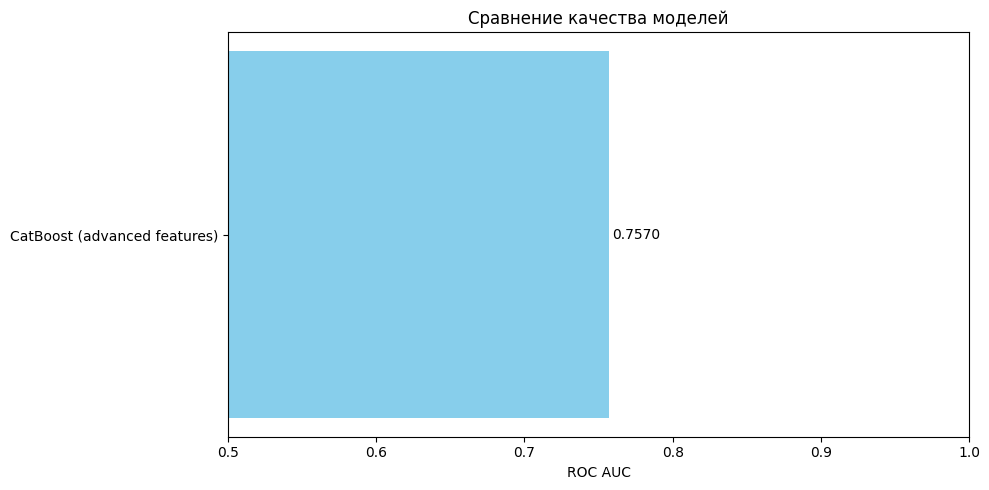

In [14]:
# ========== СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ==========

# Собираем результаты в словарь (если переменные существуют)
results = {}

# Базовая модель CatBoost (если есть)
try:
    results['CatBoost (base)'] = catboost_auc
except NameError:
    pass

# Настроенная модель (если есть)
try:
    results['CatBoost (tuned)'] = best_cb_auc
except NameError:
    pass

# Модель с новыми признаками
results['CatBoost (advanced features)'] = adv_auc

# Если выполняли отбор признаков (пока нет) – добавим позже

# Создаём DataFrame
comparison_df = pd.DataFrame(list(results.items()), columns=['Model', 'ROC AUC'])
comparison_df = comparison_df.sort_values('ROC AUC', ascending=False)

print("\n=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
print(comparison_df.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 5))
plt.barh(comparison_df['Model'], comparison_df['ROC AUC'], color='skyblue')
plt.xlabel('ROC AUC')
plt.title('Сравнение качества моделей')
plt.xlim(0.5, 1.0)
for i, v in enumerate(comparison_df['ROC AUC']):
    plt.text(v + 0.002, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()

In [15]:
# ========== ОТБОР ПРИЗНАКОВ ==========

from sklearn.feature_selection import SelectFromModel

# Используем важность из модели с новыми признаками
selector = SelectFromModel(catboost_adv, threshold=0.001, prefit=True)
X_tr_sel = selector.transform(X_tr_adv)
X_val_sel = selector.transform(X_val_adv)

selected_features = X_tr_adv.columns[selector.get_support()]
print(f"Исходное количество признаков: {X_tr_adv.shape[1]}")
print(f"Отобрано признаков: {len(selected_features)}")
print(f"Отобранные признаки: {selected_features.tolist()}")

# Обновляем список категориальных признаков
CAT_FEATURES_SEL = [col for col in CAT_FEATURES_ADV if col in selected_features]

# Обучаем модель на отобранных признаках
catboost_sel = CatBoostClassifier(
    **best_params,
    cat_features=CAT_FEATURES_SEL,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False,
    early_stopping_rounds=50
)

print("\nОбучение модели на отобранных признаках...")
catboost_sel.fit(X_tr_adv[selected_features], y_tr_adv,
                 eval_set=(X_val_adv[selected_features], y_val_adv))

sel_pred = catboost_sel.predict_proba(X_val_adv[selected_features])[:, 1]
sel_auc = roc_auc_score(y_val_adv, sel_pred)
print(f"ROC AUC после отбора: {sel_auc:.4f}")

# Добавляем в сравнение
results['CatBoost (selected features)'] = sel_auc
comparison_df = pd.DataFrame(list(results.items()), columns=['Model', 'ROC AUC'])
comparison_df = comparison_df.sort_values('ROC AUC', ascending=False)
print("\n=== ОБНОВЛЁННОЕ СРАВНЕНИЕ ===")
print(comparison_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Исходное количество признаков: 16
Отобрано признаков: 16
Отобранные признаки: ['Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'UniqueCarrier', 'Origin', 'Dest', 'Distance', 'DepHour', 'IsWeekend', 'Route', 'TimeOfDay', 'Season', 'MonthPart', 'Weekend_Evening', 'Distance_Per_Hour']

Обучение модели на отобранных признаках...
ROC AUC после отбора: 0.7570

=== ОБНОВЛЁННОЕ СРАВНЕНИЕ ===
                       Model  ROC AUC
CatBoost (advanced features) 0.756956
CatBoost (selected features) 0.756956


In [16]:
# ========== ФИНАЛЬНЫЙ САБМИТ ==========

# Выбираем лучшую модель
if 'sel_auc' in locals() and sel_auc > adv_auc:
    final_model = catboost_sel
    final_features = selected_features
    print(f"Используем модель с отбором признаков (AUC: {sel_auc:.4f})")
else:
    final_model = catboost_adv
    final_features = X_adv.columns
    print(f"Используем модель с новыми признаками (AUC: {adv_auc:.4f})")

# Подготовка тестовых данных
X_test = test_fe_adv.drop(['dep_delayed_15min'], axis=1, errors='ignore')

# Если используем отбор признаков – оставляем только нужные
if final_features is not None:
    X_test = X_test[final_features]

# Приводим категориальные признаки к типу 'category'
for col in CAT_FEATURES_ADV:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

# Предсказания
test_pred = final_model.predict_proba(X_test)[:, 1]

# Создаём сабмит
submission = pd.DataFrame({
    'id': range(len(test_pred)),
    'dep_delayed_15min': test_pred
})

submission.to_csv('/kaggle/working/submission_catboost_final.csv', index=False)
print("✅ Сабмит сохранён как submission_catboost_final.csv")
print(submission.head())

Используем модель с новыми признаками (AUC: 0.7570)
✅ Сабмит сохранён как submission_catboost_final.csv
   id  dep_delayed_15min
0   0           0.020363
1   1           0.051837
2   2           0.029400
3   3           0.312798
4   4           0.196575
